Compute L1, L2, and L-infinity distances between (1, 2, 3) and (4, 0, 6). Verify that L-inf <= L2 <= L1 always holds for any pair of points. Prove why this ordering is guaranteed.

In [6]:
import math
def l1_distance(a,b):
    return sum(abs(ai-bi) for ai,bi in zip(a,b))

In [2]:
def l2_distance(a,b):
    return math.sqrt(sum(abs(ai-bi)**2 for ai,bi in zip(a,b)))

In [3]:
def linf_distance(a, b):
    return max(abs(ai - bi) for ai, bi in zip(a, b))

In [8]:
def distance():
    a=[1,2,3]
    b=[4,0,6]
    print(f"A={a}")
    print(f"B={b}")
    print(f"Linf={linf_distance(a,b):.4f}")
    print(f"L1={l1_distance(a,b):.4f}")
    print(f"L2={l2_distance(a,b):.4f}")
    
distance()

A=[1, 2, 3]
B=[4, 0, 6]
Linf=3.0000
L1=8.0000
L2=4.6904


Create two vectors where cosine similarity is high (> 0.9) but L2 distance is large (> 10). Explain geometrically what is happening. Then create two vectors where cosine similarity is low (< 0.3) but L2 distance is small (< 0.5).

Case 1: cos=1.000, L2=15.556
Case 2: cos=0.000, L2=1.077


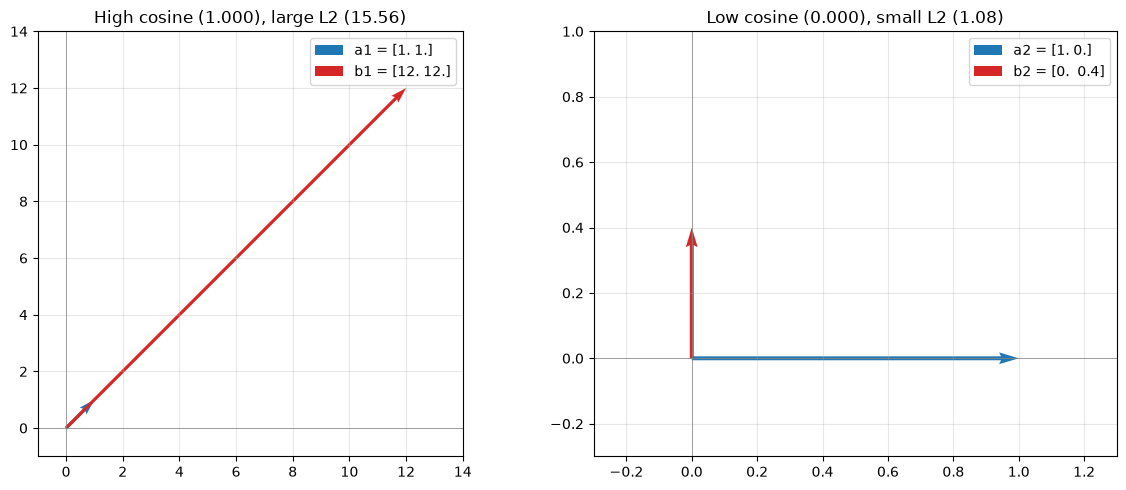

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def l2(a, b):
    return np.linalg.norm(np.array(a) - np.array(b))

# ---------- Case 1: high cosine, large L2 ----------
a1 = np.array([1.0, 1.0])
b1 = np.array([12.0, 12.0])          # same direction, 12x longer

# ---------- Case 2: low cosine, small L2 ----------
a2 = np.array([1.0, 0.0])
b2 = np.array([0.0, 0.4])            # tiny vectors, nearly orthogonal

for name, (a, b) in [("Case 1", (a1, b1)), ("Case 2", (a2, b2))]:
    print(f"{name}: cos={cosine_sim(a,b):.3f}, L2={l2(a,b):.3f}")

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Case 1
ax = axes[0]
ax.quiver(0, 0, a1[0], a1[1], angles='xy', scale_units='xy', scale=1,
          color='tab:blue', label=f'a1 = {a1}')
ax.quiver(0, 0, b1[0], b1[1], angles='xy', scale_units='xy', scale=1,
          color='tab:red', label=f'b1 = {b1}')
ax.set_xlim(-1, 14); ax.set_ylim(-1, 14)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')
ax.set_title(f"High cosine ({cosine_sim(a1,b1):.3f}), large L2 ({l2(a1,b1):.2f})")
ax.legend(); ax.grid(alpha=0.3)

# Case 2
ax = axes[1]
ax.quiver(0, 0, a2[0], a2[1], angles='xy', scale_units='xy', scale=1,
          color='tab:blue', label=f'a2 = {a2}')
ax.quiver(0, 0, b2[0], b2[1], angles='xy', scale_units='xy', scale=1,
          color='tab:red', label=f'b2 = {b2}')
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.0)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')
ax.set_title(f"Low cosine ({cosine_sim(a2,b2):.3f}), small L2 ({l2(a2,b2):.2f})")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()